# Laporan Simulasi Model Ising 2D

**Kelompok:** Balmond  
**Anggota:**  
1. Eki Permata Cahya Hati (01231007)  
2. Melky Juli Kurniawan Silalahi (01231010)  
3. Yustiara Sampe Manggoali (01231019)  

**Topik:** Kasus 3 - Fase Paramagnetik ($T = 4.0$)

---

### Pendahuluan
Pada simulasi ini, sistem magnetik disimulasikan pada suhu $T = 4.0$, yang berada jauh di atas suhu kritis teoritis ($T > T_c \approx 2.27$). 

**Tujuan:**
Mengamati hilangnya keteraturan spin akibat agitasi termal yang mendominasi interaksi pertukaran spin. Dalam kondisi ini, diharapkan nilai magnetisasi rata-rata berfluktuasi secara acak di sekitar 0 dengan amplitudo kecil, mengindikasikan sistem berada dalam fase paramagnetik.

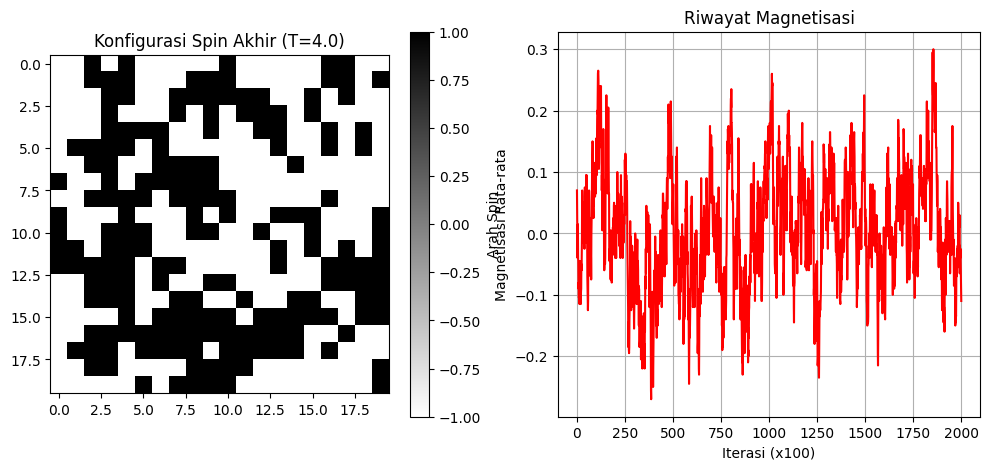

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter dasar untuk simulasi
ukuran_kisi = 20
suhu = 4.0
jumlah_langkah = 200000

# Mulai dengan membuat papan spin acak (Hot Start)
papan_spin = np.random.choice([-1, 1], size=(ukuran_kisi, ukuran_kisi))

# Wadah untuk mencatat perubahan magnetisasi
catatan_magnetisasi = []

# --- Simulasi Ising ---

# 1. Menghitung perubahan energi
def hitung_energi_tetangga(kisi, i, j):
    spin = kisi[i, j]
    # Mencari tetangga atas, bawah, kiri, kanan
    # Menggunakan % ukuran_kisi agar tidak error di pinggir kisi
    atas = kisi[(i-1) % ukuran_kisi, j]
    bawah = kisi[(i+1) % ukuran_kisi, j]
    kiri = kisi[i, (j-1) % ukuran_kisi]
    kanan = kisi[i, (j+1) % ukuran_kisi]
    
    total_tetangga = atas + bawah + kiri + kanan
    delta_e = 2 * spin * total_tetangga
    return delta_e

# 2. Proses simulasi
for langkah in range(jumlah_langkah):
    # Pilih koordinat acak
    i = np.random.randint(0, ukuran_kisi)
    j = np.random.randint(0, ukuran_kisi)
    
    perubahan = hitung_energi_tetangga(papan_spin, i, j)
    
    # Kriteria Metropolis (dijelaskan perlahan)
    if perubahan < 0:
        # Jika energi turun, terima perubahan
        papan_spin[i, j] = papan_spin[i, j] * -1
    else:
        # Jika energi naik, cek peluang
        peluang = np.exp(-perubahan / suhu)
        if np.random.rand() < peluang:
            papan_spin[i, j] = papan_spin[i, j] * -1
            
    # Catat data
    if langkah % 100 == 0:
        # Menggunakan np.mean untuk menghitung rata-rata secara langsung
        rata_rata = np.mean(papan_spin)
        catatan_magnetisasi.append(rata_rata)

plt.figure(figsize=(12, 5))

# Plot kondisi akhir kisi
plt.subplot(1, 2, 1)
plt.imshow(papan_spin, cmap='binary', vmin=-1, vmax=1)
plt.colorbar(label='Arah Spin')
plt.title(f"Konfigurasi Spin Akhir (T={suhu})")

# Plot grafik magnetisasi
plt.subplot(1, 2, 2)
plt.plot(catatan_magnetisasi, color='red')
plt.title("Riwayat Magnetisasi")
plt.xlabel("Iterasi (x100)")
plt.ylabel("Magnetisasi Rata-rata")
plt.grid(True)
plt.show()

### Analisis Hasil

* **Konfigurasi Spin**: Tampilan kisi sangat acak menyerupai *white noise*. Energi termal yang tinggi mengacaukan ikatan kopling spin tetangga, sehingga orientasi spin menjadi tidak teratur (*disordered state*).
* **Magnetisasi (\(M\))**: Magnetisasi rata-rata berfluktuasi cepat di sekitar nilai nol (\(M \approx 0\)). Fluktuasi termal yang dominan membuat orientasi spin berganti arah dengan cepat secara acak, meniadakan magnetisasi total sistem.
* **Fisis**: Terjadi transisi ke fase paramagnetik murni. Energi termal mendominasi interaksi kopling, merusak keteraturan makroskopik sehingga sistem tidak memiliki magnetisasi spontan.